# run the initial stuff

In [ ]:
import os
import sys
import time
import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
for filename in ['base_waves_class_library',
                 'moments_function_library',
                 'polyfit_function_library',
                 'scatter_function_library',
                 'database_config_library',
                 'gmm_library',]:
    !jupyter nbconvert --to python '/classes/{filename}.ipynb'

In [ ]:
import base_waves_class_library as bwl
import moments_function_library as mfl
import polyfit_function_library as pfl
import scatter_function_library as sfl
import database_config_library  as dbl
import gmm_library              as gmm

In [ ]:
folder  = '/your/folder/here/'

# Return Signal Databases

convolve the scatter distributions from previous delta and GMM databases with interrogating waves of chosen design and collect key data for final databases

### test one chunk from every config before running the big loop

In [ ]:
dbconfig    = dbl.DB_Config()
dbconfig.edit_base_type('discrete')
for scatterer in ['delta', 'gmm']:
    dbconfig.edit_scatterer_type(scatterer)
    for fit_order in [4, 6]:
        dbconfig.set_testing_vars(max_fit_order=fit_order)
        for noise_val in [20, 40]:
            for signallen in [20]:
                dbconfig.make_interrogating_wave(SignalLen=signallen)
                print(len(dbconfig.t))
                dbconfig.make_feature_columns(corrs=False)
                dbconfig.add_noise_vals(noise_val)
                print(scatterer, fit_order, noise_val, signallen)
                source_chunk, test_chunk = dbconfig.test_one_chunk(folder, chunk_size=5, return_source=True)
                display(test_chunk[['mean', 'std', 'skew', 'kurtosis', 'spectral_mean_pred', 'spectral_std_pred',
                                    'spectral_skew_pred', 'spectral_kurt_pred']])

2000
delta 4 20 20
Test chunk passed.
Rows tested: 5
Columns produced: 31
scatterer=delta, base_type=discrete, SignalLen=20, snr=20


,mean,std,skew,kurtosis,spectral_mean_pred,spectral_std_pred,spectral_skew_pred,spectral_kurt_pred
0,-0.051,0.258107,-0.009529,1.529783,-0.044999,0.256696,0.155495,1.382563
1,0.171,0.381234,-0.446193,1.234727,0.132842,0.381885,-0.592262,1.184031
2,-0.012,0.309218,-0.253833,1.220429,-0.004122,0.305192,-0.179163,1.032934
3,-0.255,0.256817,0.990777,2.135795,-0.226072,0.271369,1.525687,3.341530
4,0.096,0.282956,-0.911108,1.871307,0.096894,0.278430,-0.907567,1.650810


2000
delta 4 40 20
Test chunk passed.
Rows tested: 5
Columns produced: 31
scatterer=delta, base_type=discrete, SignalLen=20, snr=40


,mean,std,skew,kurtosis,spectral_mean_pred,spectral_std_pred,spectral_skew_pred,spectral_kurt_pred
0,-0.051,0.258107,-0.009529,1.529783,-0.044896,0.255578,0.152720,1.350925
1,0.171,0.381234,-0.446193,1.234727,0.132010,0.381096,-0.585969,1.176342
2,-0.012,0.309218,-0.253833,1.220429,-0.005040,0.304959,-0.173489,1.025950
3,-0.255,0.256817,0.990777,2.135795,-0.227719,0.269665,1.534050,3.363481
4,0.096,0.282956,-0.911108,1.871307,0.096948,0.279766,-0.903515,1.664117


2000
delta 6 20 20
Test chunk passed.
Rows tested: 5
Columns produced: 31
scatterer=delta, base_type=discrete, SignalLen=20, snr=20


...

,mean,std,skew,kurtosis,spectral_mean_pred,spectral_std_pred,spectral_skew_pred,spectral_kurt_pred
0,0.046981,0.249454,-0.471626,1.418552,0.046931,0.247894,-0.474876,1.250190
1,0.140022,0.200188,-0.282352,2.795316,0.130959,0.199654,-0.871979,3.077056
2,-0.018016,0.160197,0.196095,2.291058,-0.017831,0.159720,0.211895,2.009736
3,-0.063985,0.076313,2.616124,9.725672,-0.064040,0.076388,2.544134,9.385065
4,-0.037984,0.143415,-0.237039,1.380971,-0.037268,0.143212,-0.114413,1.327608


2000
gmm 6 20 20
Test chunk passed.
Rows tested: 5
Columns produced: 29
scatterer=gmm, base_type=discrete, SignalLen=20, snr=20


,mean,std,skew,kurtosis,spectral_mean_pred,spectral_std_pred,spectral_skew_pred,spectral_kurt_pred
0,0.046981,0.249454,-0.471626,1.418552,0.047958,0.251164,-0.462731,1.465176
1,0.140022,0.200188,-0.282352,2.795316,0.138219,0.201456,-0.509153,3.198302
2,-0.018016,0.160197,0.196095,2.291058,-0.016673,0.159260,0.342190,1.062195
3,-0.063985,0.076313,2.616124,9.725672,-0.065838,0.062150,-2.398373,-130.133494
4,-0.037984,0.143415,-0.237039,1.380971,-0.037635,0.144782,-0.263055,2.918519


2000
gmm 6 40 20
Test chunk passed.
Rows tested: 5
Columns produced: 29
scatterer=gmm, base_type=discrete, SignalLen=20, snr=40


,mean,std,skew,kurtosis,spectral_mean_pred,spectral_std_pred,spectral_skew_pred,spectral_kurt_pred
0,0.046981,0.249454,-0.471626,1.418552,0.046920,0.249539,-0.474069,1.425418
1,0.140022,0.200188,-0.282352,2.795316,0.139456,0.200484,-0.378008,2.919596
2,-0.018016,0.160197,0.196095,2.291058,-0.018016,0.159941,0.200095,2.134140
3,-0.063985,0.076313,2.616124,9.725672,-0.063913,0.077070,2.606492,11.453351
4,-0.037984,0.143415,-0.237039,1.380971,-0.037780,0.143543,-0.189899,1.364757


In [ ]:
dbconfig    = dbl.DB_Config()
dbconfig.edit_base_type('discrete')
dbconfig.edit_scatterer_type('delta')
dbconfig.set_testing_vars(max_fit_order=6)
dbconfig.make_interrogating_wave(SignalLen=20)
dbconfig.make_feature_columns(corrs=False)
dbconfig.add_noise_vals(20)
source_chunk, test_chunk = dbconfig.test_one_chunk(folder, chunk_size=5, return_source=True, plot=False)
display(test_chunk[['mean', 'std', 'skew', 'kurtosis', 'spectral_mean_pred', 'spectral_std_pred',
                    'spectral_skew_pred', 'spectral_kurt_pred']])

### run the full loop
this will probably take days.

In [ ]:
dbconfig    = dbl.DB_Config()
for base_type in ['discrete']:
    dbconfig.edit_base_type(base_type)
    for scatterer in ['delta', 'gmm']:
        dbconfig.edit_scatterer_type(scatterer)
        for SignalLen in [20]:
            dbconfig.make_interrogating_wave(SignalLen)
            for snr in ['NA', 0, 10, 20, 30, 40]:
                dbconfig.add_noise_vals(snr)
                for fit_order in [4, 6]:
                    dbconfig.set_testing_vars(max_fit_order=fit_order)
                    # dbconfig.set_diagnostics(True)
                    dbconfig.make_feature_columns(corrs=True)
                    dbconfig.make_database(folder)

### plot the base interrogating signal

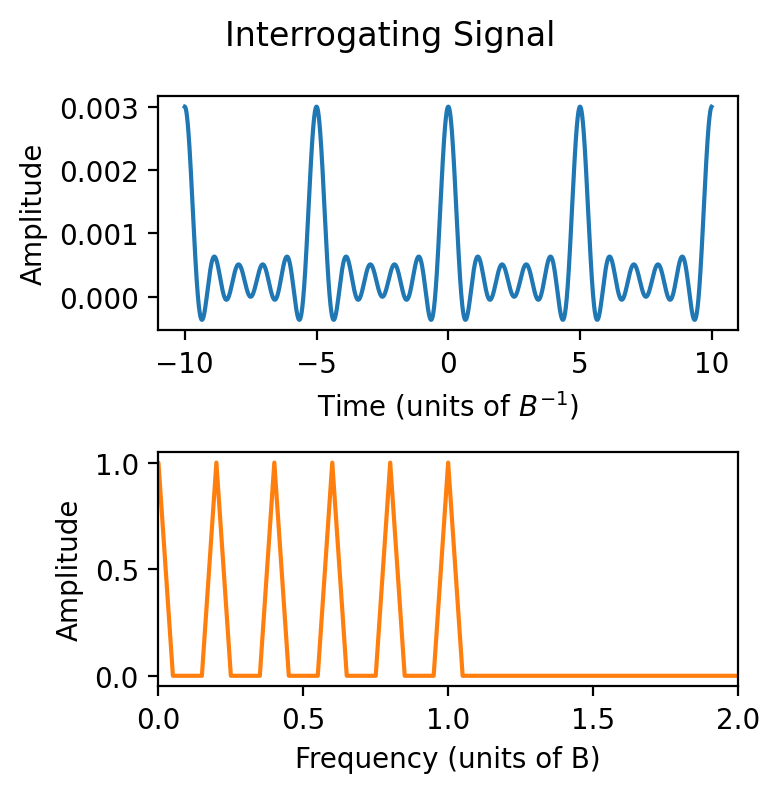

In [ ]:
dbconfig    = dbl.DB_Config()

dbconfig.edit_base_type('discrete')
dbconfig.make_interrogating_wave(20)

fftsig      = np.fft.fft(dbconfig.sr.signal)
freqs       = np.fft.fftfreq(len(dbconfig.sr.t), d=dbconfig.sr.t[1] - dbconfig.sr.t[0])

plt.rcParams['figure.dpi'] = 200
fig, axs    = plt.subplots(2, 1, figsize=(4, 4))

fig.suptitle('Interrogating Signal')
axs[0].plot(dbconfig.sr.t, np.real(dbconfig.sr.signal)/np.max(np.abs(fftsig)))
axs[0].set_xlabel(r'Time (units of $B^{-1}$)')
axs[0].set_ylabel('Amplitude')

axs[1].plot(np.fft.fftshift(freqs), np.fft.fftshift(np.abs(fftsig))/np.max(np.abs(fftsig)), c='tab:orange')
axs[1].set_xlim(0, 2)
axs[1].set_xlabel('Frequency (units of B)')
axs[1].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

### plot two scatterers
one from the delta set, one from the GMM set. additionally plot how each scatterer shapes the return signal.

In [ ]:
folder      = folder  = '/your/folder/here/'
moment_cols = ['mean', 'std', 'skew', 'kurtosis']
delta_db    = pd.read_csv(os.path.join(folder, 'delta_database.csv'))
gmm_db      = pd.read_csv(os.path.join(folder, 'gmm_database.csv'))

# delta_row   = delta_db.iloc[124637]
# gmm_row     = gmm_db.iloc[105651]

delta_row   = delta_db[(delta_db['std'] > 0.25) & (np.abs(delta_db['skew']) < .5)].sample(1).iloc[0]
diff        = gmm_db[moment_cols].values - delta_row[moment_cols].values
gmm_row     = gmm_db.iloc[np.argmin(np.linalg.norm(diff, axis=1))]

print(delta_row[moment_cols])
print('')
print(gmm_row[moment_cols])

mean       -0.134000
std         0.285174
skew        0.273098
kurtosis    1.641196
Name: 124637, dtype: float64

mean          -0.134
std         0.285153
skew        0.273143
kurtosis    1.641213
Name: 105651, dtype: object


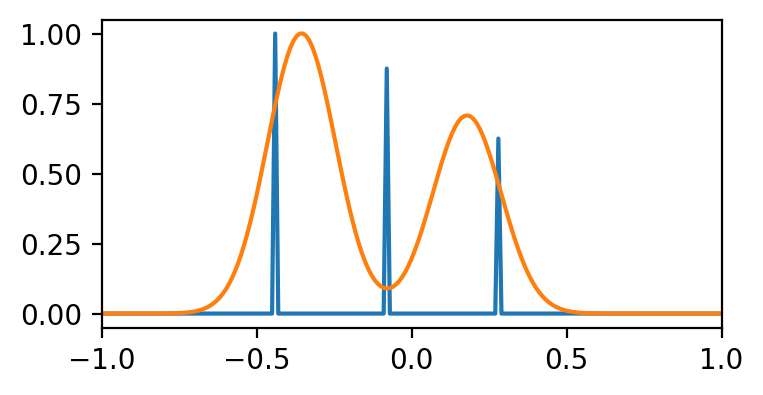

In [ ]:
dbconfig        = dbl.DB_Config()

dbconfig.edit_base_type('discrete')
dbconfig.make_interrogating_wave(20)

base            = dbconfig.sr
fftsig          = np.fft.fftshift(np.fft.fft(base.signal))
freqs           = np.fft.fftshift(np.fft.fftfreq(len(base.t), d=base.t[1] - base.t[0]))
d_scatter       = sfl.Delta(dbconfig.sr.t, loc1=delta_row['loc_1'], loc2=delta_row['loc_2'], loc3=delta_row['loc_3'],
                            amp1=delta_row['amp_1'], amp2=delta_row['amp_2'], amp3=delta_row['amp_3']).scatter
g_scatter       = gmm.gmm_pdf(base.t, [gmm_row['mu1'], gmm_row['mu2'], gmm_row['sigma'], gmm_row['w1']])
g_fft           = np.fft.fftshift(np.fft.fft(g_scatter))
d_fft           = np.fft.fftshift(np.fft.fft(d_scatter))
delta_return    = base.create_return_wave(d_scatter, add_noise=False, real=False)
gmm_return      = base.create_return_wave(g_scatter, add_noise=False, real=False)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = (4, 2)
plt.plot(base.t, np.real(d_scatter)/np.max(np.abs(d_scatter)))
plt.plot(base.t, np.real(g_scatter)/np.max(np.abs(g_scatter)))
plt.xlim(-1, 1)
plt.show()

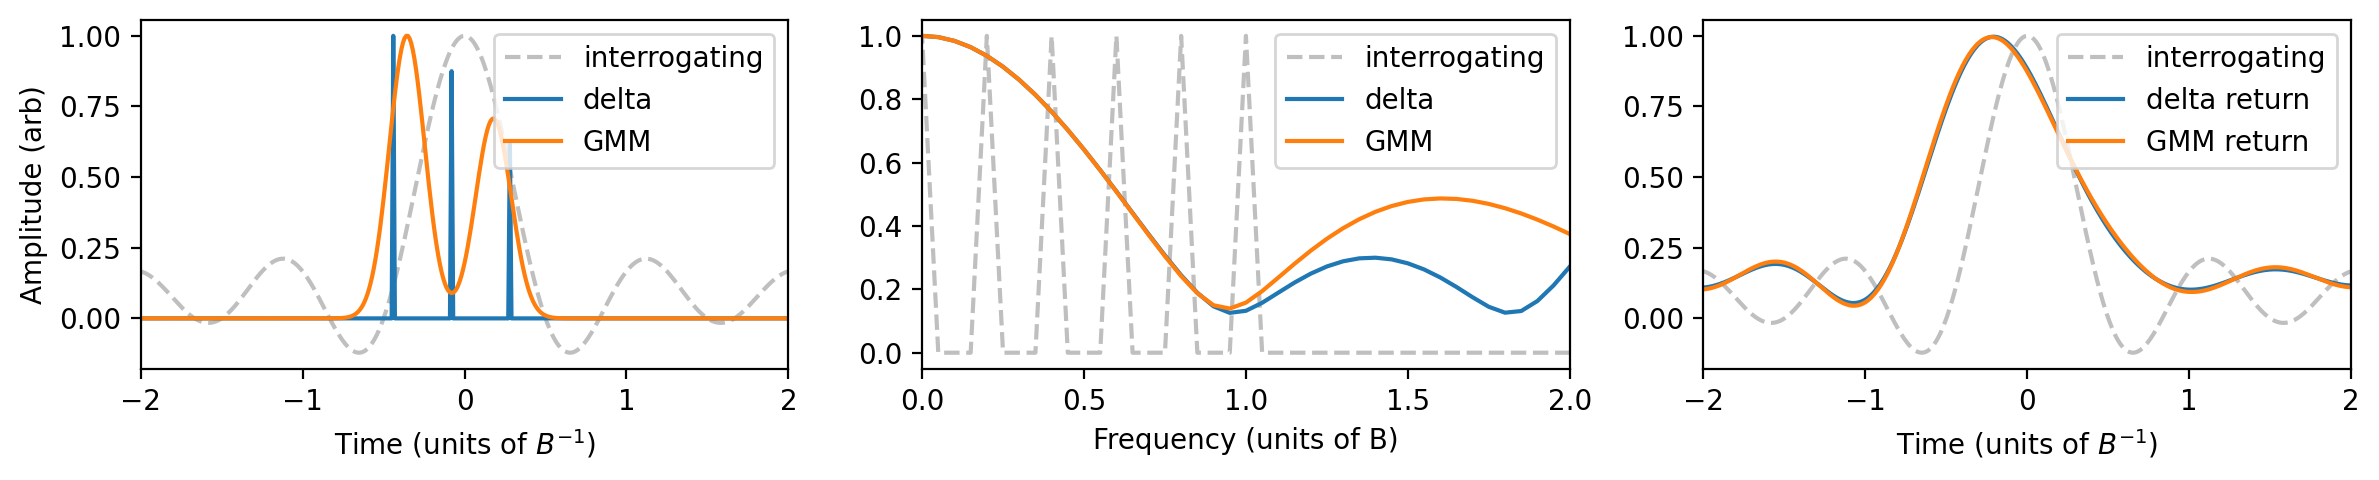

In [ ]:
plt.rcParams['figure.dpi'] = 200
fig, axs = plt.subplots(1, 3, figsize=(12, 2.5))

axs[0].plot(base.t, np.real(base.signal)/np.max(np.abs(base.signal)), label='interrogating', alpha=0.5, c='gray', ls='--')
axs[0].plot(base.t, np.real(d_scatter)/np.max(np.abs(d_scatter)), label='delta')
axs[0].plot(base.t, np.real(g_scatter)/np.max(np.abs(g_scatter)), label='GMM')

axs[1].plot(freqs, np.abs(fftsig)/np.max(np.abs(fftsig)), label='interrogating', alpha=0.5, c='gray', ls='--')
axs[1].plot(freqs, np.abs(d_fft)/np.max(np.abs(d_fft)), label='delta')
axs[1].plot(freqs, np.abs(g_fft)/np.max(np.abs(g_fft)), label='GMM')

axs[2].plot(base.t, np.real(base.signal)/np.max(np.abs(base.signal)), label='interrogating', alpha=0.5, c='gray', ls='--')
axs[2].plot(base.t, np.real(delta_return)/np.max(np.abs(delta_return)), label='delta return')
axs[2].plot(base.t, np.real(gmm_return)/np.max(np.abs(gmm_return)), label='GMM return')

axs[0].legend()
axs[1].legend()
axs[2].legend()

axs[0].set_xlim(-2, 2)
axs[1].set_xlim(0, 2)
axs[2].set_xlim(-2, 2)

axs[0].set_ylabel('Amplitude (arb)')
axs[0].set_xlabel('Time (units of $B^{-1}$)')
axs[1].set_xlabel('Frequency (units of B)')
axs[2].set_xlabel('Time (units of $B^{-1}$)')

plt.tight_layout()
plt.show()